In [150]:
import pandas as pd
import numpy as np

In [151]:
df=pd.read_csv("laptop_data.csv")
df.head()
df.shape
df.duplicated().sum()
df.isna().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


Pre-Processing

In [152]:
df=df.drop(columns=["Unnamed: 0"])
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [153]:
df['Ram']=df['Ram'].str.replace('GB','').astype('int32')

In [154]:
df['Weight']=df['Weight'].str.replace('kg','').astype('float32')

EDA

<Axes: xlabel='Price', ylabel='Count'>

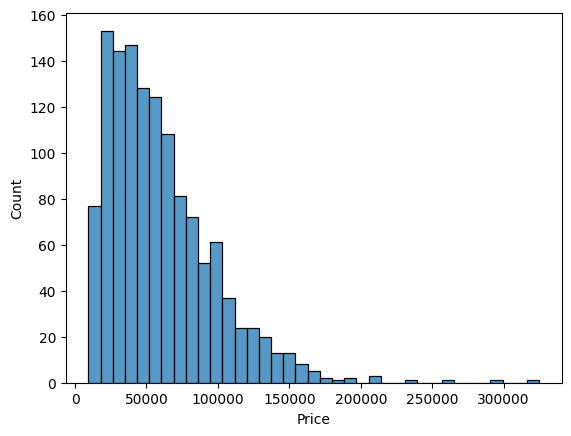

In [155]:
import seaborn as sns
sns.histplot(df["Price"])

<Axes: xlabel='Company', ylabel='count'>

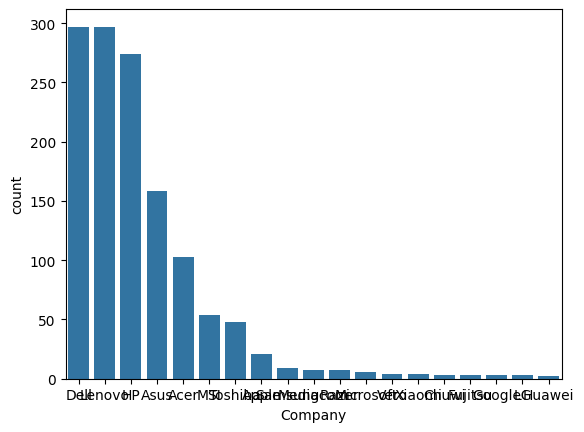

In [156]:
sns.barplot(df["Company"].value_counts())

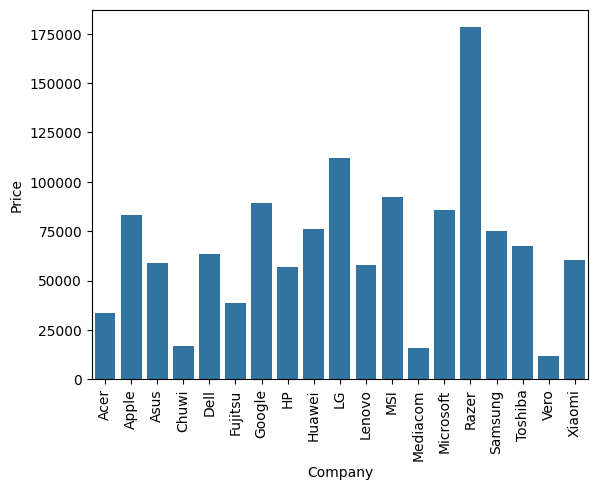

In [157]:
import matplotlib.pyplot as plt
sns.barplot(df.groupby("Company")['Price'].mean())
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName', ylabel='count'>

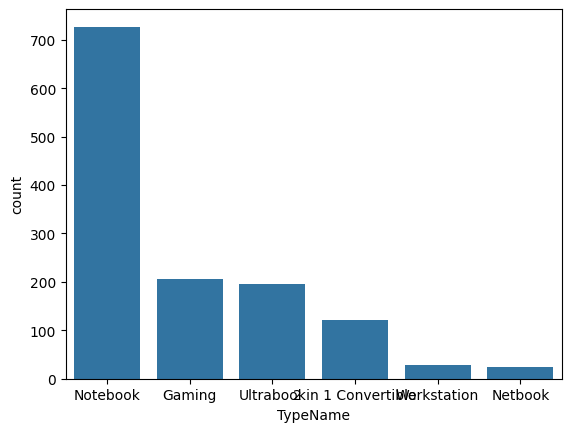

In [158]:
sns.barplot(df["TypeName"].value_counts())

<Axes: xlabel='TypeName', ylabel='Price'>

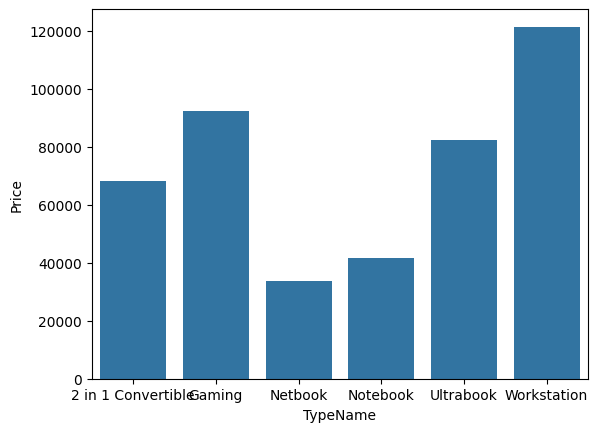

In [159]:
sns.barplot(df.groupby("TypeName")["Price"].mean())

<Axes: xlabel='Inches', ylabel='Count'>

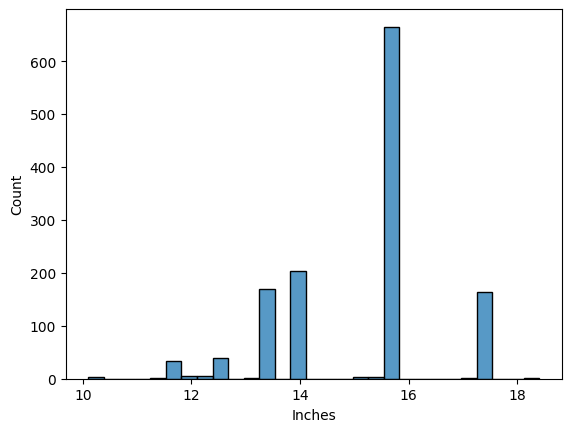

In [160]:
sns.histplot(df["Inches"])

<Axes: xlabel='Inches', ylabel='Price'>

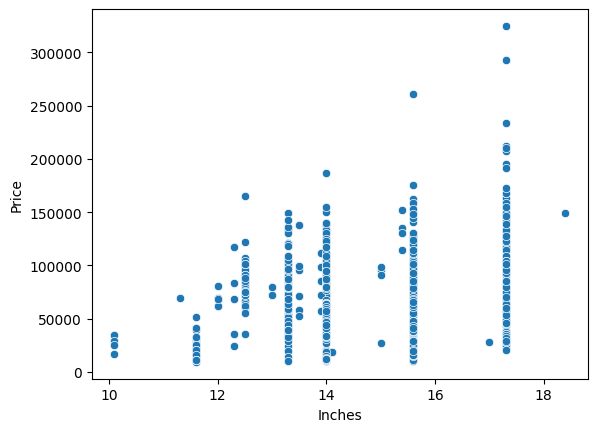

In [161]:
sns.scatterplot(x=df["Inches"],y=df["Price"])

In [162]:
df["ScreenResolution"].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


<Axes: xlabel='Touchscreen', ylabel='count'>

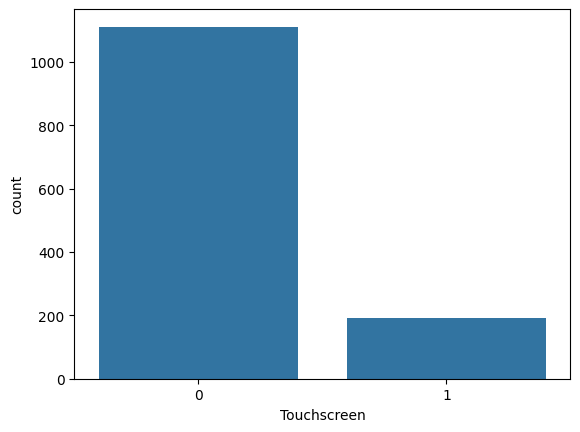

In [163]:
df["Touchscreen"]=df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in x else 0)
sns.barplot(df["Touchscreen"].value_counts())

<Axes: xlabel='Touchscreen', ylabel='Price'>

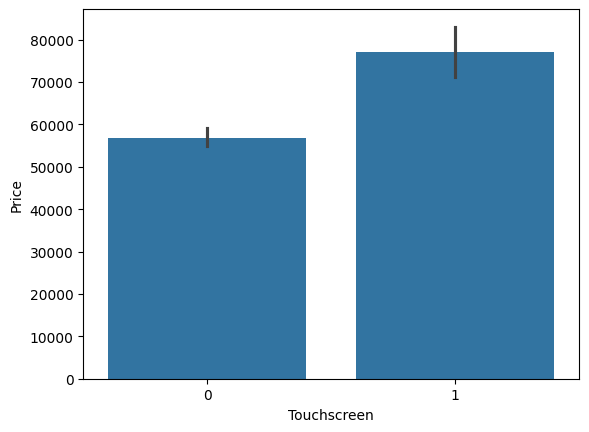

In [164]:
sns.barplot(x=df["Touchscreen"],y=df["Price"])

<Axes: xlabel='IPS', ylabel='count'>

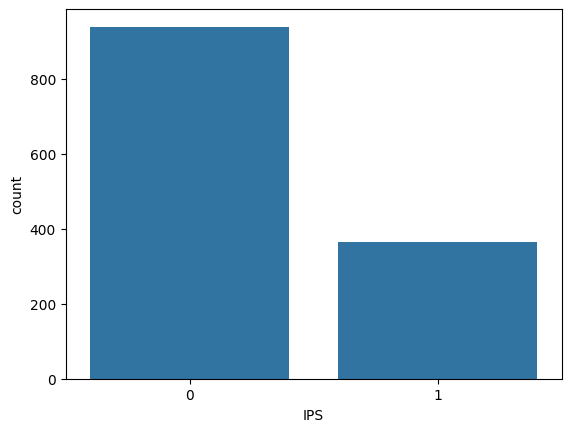

In [165]:
df["IPS"]=df["ScreenResolution"].apply(lambda x: 1 if "IPS" in x else 0)
sns.barplot(df["IPS"].value_counts())

<Axes: xlabel='IPS', ylabel='Price'>

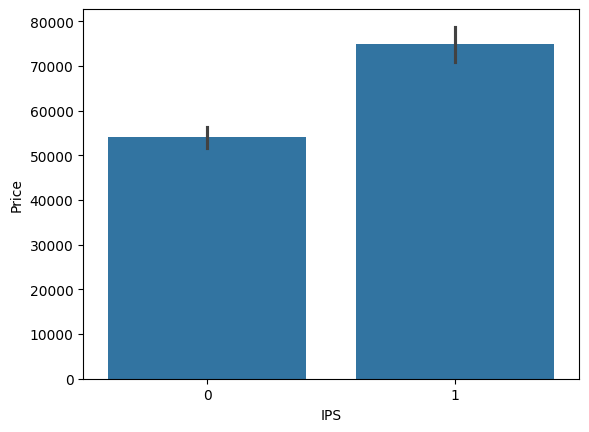

In [166]:
sns.barplot(x=df["IPS"],y=df["Price"])

In [167]:
#resolution
new=df["ScreenResolution"].str.split("x",n=1,expand=True)
new

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1298,IPS Panel Full HD / Touchscreen 1920,1080
1299,IPS Panel Quad HD+ / Touchscreen 3200,1800
1300,1366,768
1301,1366,768


In [168]:
df["X_res"]=new[0].apply(lambda x: x[-4::]).astype('int32')
df["Y_res"]=new[1].astype('int32')

In [169]:
df.select_dtypes(include="number").corr()["Price"]

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
IPS,0.252208
X_res,0.556529
Y_res,0.552809


In [170]:
df["ppi"]=((df["X_res"]**2 + df["Y_res"]**2)**0.5)/(df["Inches"])

In [171]:
df.select_dtypes(include='number').corr()["Price"]

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
IPS,0.252208
X_res,0.556529
Y_res,0.552809
ppi,0.473487


In [172]:
df=df.drop(columns=["ScreenResolution","X_res","Y_res","Inches"])

In [173]:
df["Cpu"].value_counts()

,count
Cpu,
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core i5 7200U 2.70GHz,1
Intel Core M M7-6Y75 1.2GHz,1
Intel Core M 6Y54 1.1GHz,1


In [174]:
df["Cpu_name"]=df["Cpu"].apply(lambda x: " ".join(x.split()[0:3]))
df.tail()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu_name
1298,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.64,1,1,157.350512,Intel Core i7
1299,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.72,1,1,276.053530,Intel Core i7
1300,Lenovo,Notebook,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12,0,0,111.935204,Intel Celeron Dual
1301,HP,Notebook,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.92,0,0,100.454670,Intel Core i7
1302,Asus,Notebook,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.32,0,0,100.454670,Intel Celeron Dual


In [175]:
def fetch_processor(text):
  if text.lower()=="intel core i7" or text.lower()=="intel core i5" or text.lower()=="intel core i3":
    return text
  else:
    if text.split()[0]=="Intel":
      return "Other Intel Processor"
    else:
      return "AMD Processor"

In [176]:
df["Cpu_brand"]=df["Cpu_name"].apply(fetch_processor)

<Axes: xlabel='Cpu_brand', ylabel='count'>

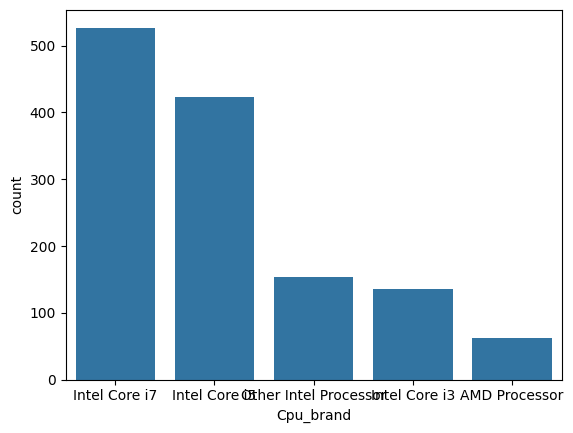

In [177]:
sns.barplot(df["Cpu_brand"].value_counts())

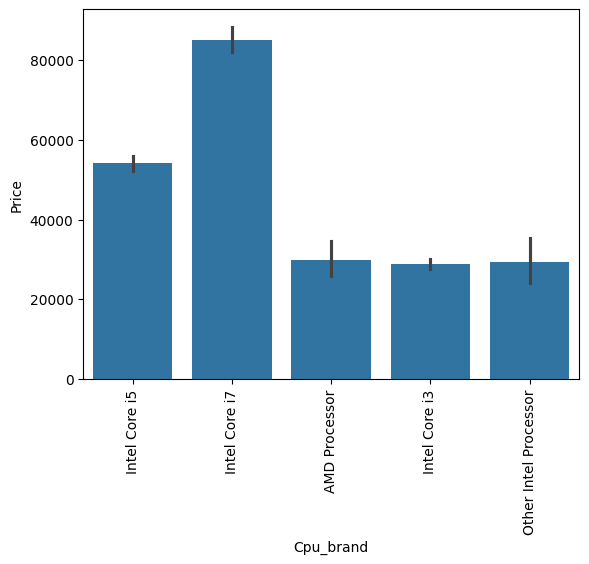

In [178]:
sns.barplot(x=df["Cpu_brand"],y=df["Price"])
plt.xticks(rotation="vertical")
plt.show()

In [179]:
df=df.drop(columns=["Cpu","Cpu_name"])

<Axes: xlabel='Ram', ylabel='count'>

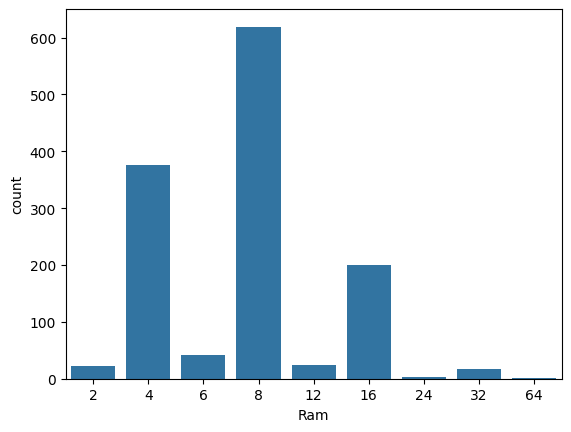

In [180]:
sns.barplot(df["Ram"].value_counts())

<Axes: xlabel='Ram', ylabel='Price'>

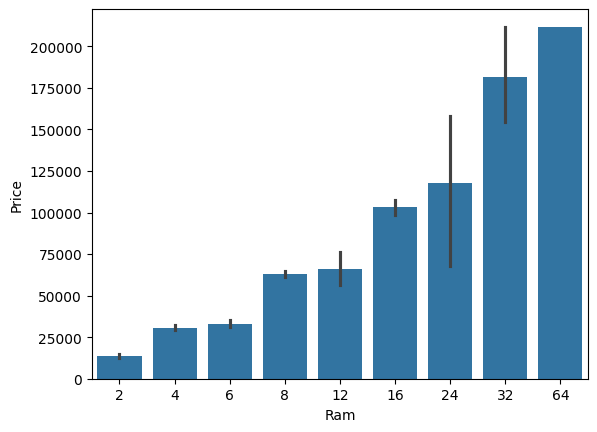

In [181]:
sns.barplot(x=df["Ram"],y=df["Price"])

In [182]:
df["Memory"].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [183]:
df["Memory"]=df['Memory'].astype(str).replace('\.0','',regex=True)
df["Memory"]=df["Memory"].str.replace('GB','')
df["Memory"]=df["Memory"].str.replace('TB',"000")

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1472/729883539.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Memory"]=df['Memory'].astype(str).replace('\.0','',regex=True)


In [184]:
new=df["Memory"].str.split('+',n=1,expand=True)

In [185]:
df["first"]=new[0]
df["first"]=df["first"].str.strip()
df["second"]=new[1]

In [186]:
df["Layer1HDD"]=df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"]=df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"]=df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"]=df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

In [187]:
#remove all non digit characters
df["first"]=df["first"].str.replace(r'\D','',regex=True)

In [188]:
#didn't have any second layer (no '+')
df["second"]=df["second"].fillna("0")

In [189]:
df["Layer2HDD"]=df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"]=df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"]=df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"]=df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)


In [190]:
df["second"]=df['second'].str.replace(r'\D','',regex=True)
df["first"]=df["first"].astype(int)
df["second"]=df["second"].astype(int)


In [191]:
df["HDD"]=(df["first"]*df["Layer1HDD"])+(df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"])+(df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"])+(df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"])+(df["second"]*df["Layer2Flash_Storage"])

In [192]:
df=df.drop(columns=["Layer1HDD","Layer2HDD","Layer1SSD","Layer2SSD","Layer1Hybrid","Layer2Hybrid","Layer1Flash_Storage","Layer2Flash_Storage","first","second","Memory"])

In [193]:
df.select_dtypes(include="number").corr()["Price"]

,Price
Ram,0.743007
Weight,0.210370
Price,1.000000
Touchscreen,0.191226
IPS,0.252208
ppi,0.473487
HDD,-0.096441
SSD,0.670799
Hybrid,0.007989
Flash_Storage,-0.040511


In [194]:
df=df.drop(columns=['Hybrid','Flash_Storage'])

In [195]:
df["Gpu"].value_counts()

,count
Gpu,
Intel HD Graphics 620,281
Intel HD Graphics 520,185
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48
...,...
Nvidia Quadro M500M,1
AMD Radeon R7 M360,1
Nvidia Quadro M3000M,1


In [196]:
df["Gpu_Brand"]=df["Gpu"].apply(lambda x: x.split()[0])
df["Gpu_Brand"].value_counts()

,count
Gpu_Brand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [197]:
df=df[df["Gpu_Brand"]!="ARM"]
df["Gpu_Brand"].value_counts()

,count
Gpu_Brand,
Intel,722
Nvidia,400
AMD,180


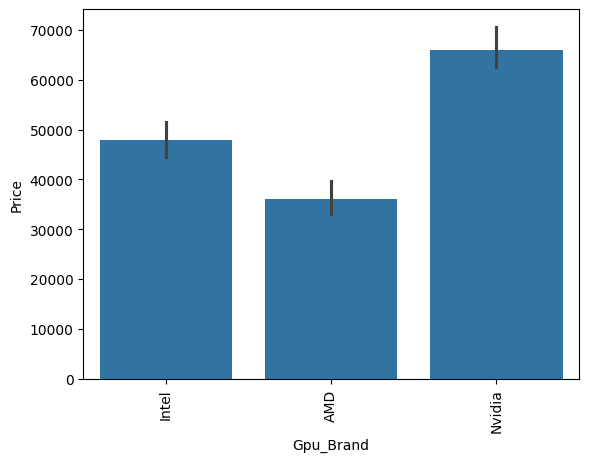

In [198]:
sns.barplot(x=df["Gpu_Brand"],y=df["Price"],estimator="median")
plt.xticks(rotation="vertical")
plt.show()

In [199]:
df=df.drop(columns=["Gpu"])

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64


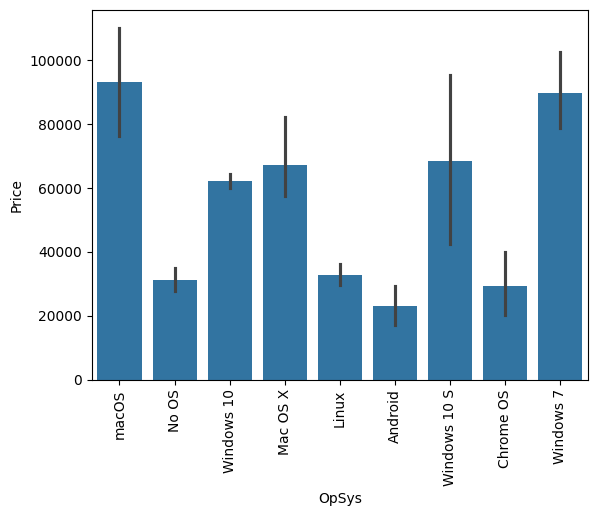

In [200]:
print(df["OpSys"].value_counts())
sns.barplot(x=df["OpSys"],y=df["Price"])
plt.xticks(rotation="vertical")
plt.show()

In [201]:
def categorize_os(text):
  if "Windows" in text:
    return "Windows"
  elif "mac" in text.lower():
    return "mac"
  else:
    return "Others/No Os/Linux"

In [202]:
df["os"]=df["OpSys"].apply(categorize_os)
df=df.drop(columns=["OpSys"])

<Axes: xlabel='os', ylabel='Price'>

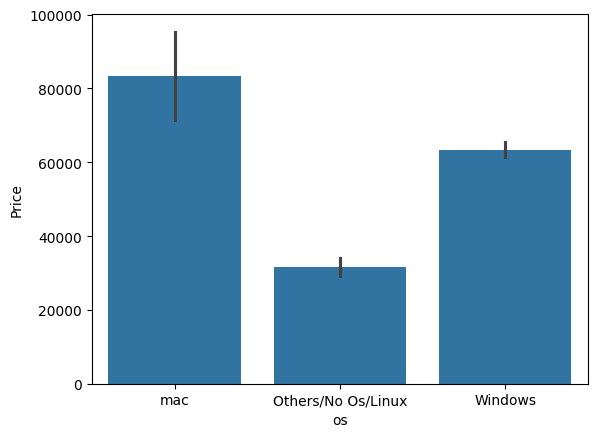

In [203]:
sns.barplot(x=df["os"],y=df["Price"])

<Axes: xlabel='Weight', ylabel='Count'>

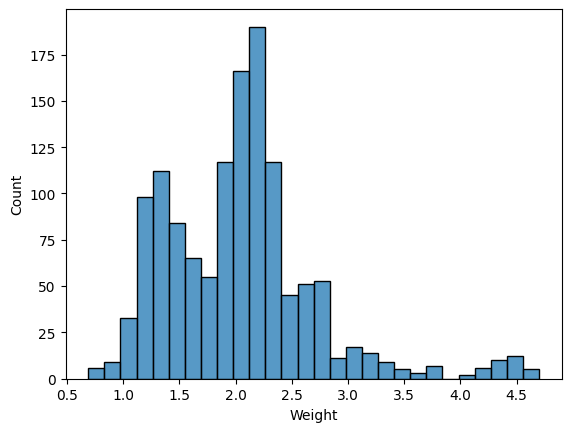

In [204]:
sns.histplot(df["Weight"])

<Axes: >

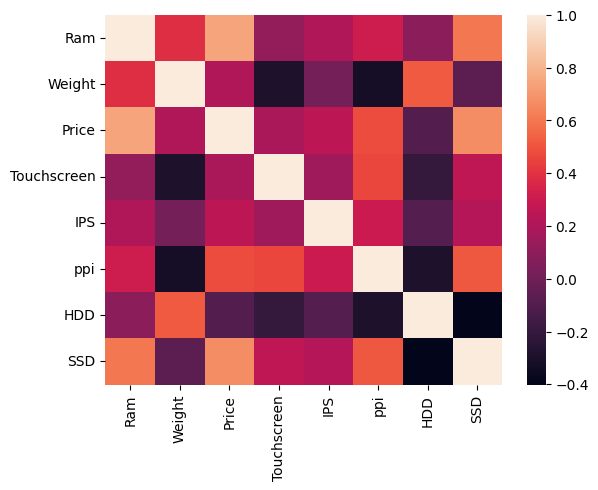

In [205]:
sns.heatmap(df.select_dtypes(include="number").corr())

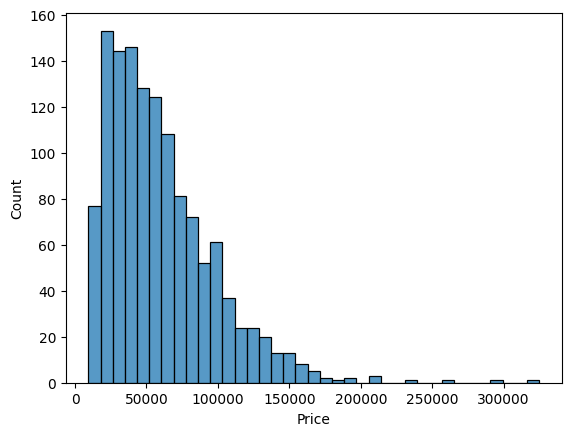

<Axes: xlabel='Price', ylabel='Count'>

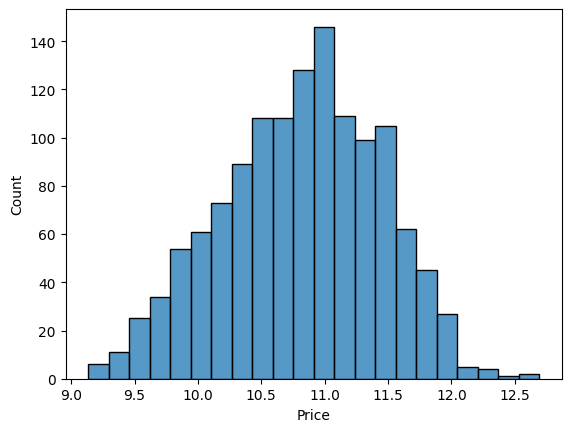

In [206]:
#Our target column is skewed
sns.histplot(df["Price"])
plt.show()
sns.histplot(np.log(df["Price"]))

In [207]:
X=df.drop(columns=["Price"])
y=np.log(df["Price"])

In [208]:
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=2)

In [209]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,RidgeCV,LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error

In [210]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,IPS,ppi,Cpu_brand,HDD,SSD,Gpu_Brand,os
183,Toshiba,Notebook,8,2.00,0,0,100.454670,Intel Core i5,0,128,Intel,Windows
1141,MSI,Gaming,8,2.40,0,0,141.211998,Intel Core i7,1000,128,Nvidia,Windows
1049,Asus,Netbook,4,1.20,0,0,135.094211,Other Intel Processor,0,0,Intel,Others/No Os/Linux
1020,Dell,2 in 1 Convertible,4,2.08,1,1,141.211998,Intel Core i3,1000,0,Intel,Windows
878,Dell,Notebook,4,2.18,0,0,141.211998,Intel Core i5,1000,128,Nvidia,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
466,Acer,Notebook,4,2.20,0,0,100.454670,Intel Core i3,500,0,Nvidia,Windows
299,Asus,Ultrabook,16,1.63,0,0,141.211998,Intel Core i7,0,512,Nvidia,Windows
493,Acer,Notebook,8,2.20,0,0,100.454670,AMD Processor,1000,0,AMD,Windows
527,Lenovo,Notebook,8,2.20,0,0,100.454670,Intel Core i3,2000,0,Nvidia,Others/No Os/Linux


Linear Regressor

In [211]:
#We need to transform our categorical columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
step1=ColumnTransformer(transformers=[(
    "col_tnf",OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11]
                                 )],remainder="passthrough")        #columns on which we want apply the transformation
step2=LinearRegression()
pipe=Pipeline([("step1",step1),('step2',step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("R2 Score: ",r2_score(y_test,y_pred))
print("MAE",np.exp(mean_absolute_error(y_test,y_pred)))

R2 Score:  0.8073277448418652
MAE 1.2338980193970541


Ridge

In [212]:
step1=ColumnTransformer(transformers=[("col_tnf",OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11])],remainder="passthrough")
step2=Ridge(alpha=13)
pipe=Pipeline([("step1",step1),('step2',step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("R2 Score: ",r2_score(y_test,y_pred))
print("MAE",np.exp(mean_absolute_error(y_test,y_pred)))

R2 Score:  0.8127353277110796
MAE 1.2335243916981014


Lasso

In [213]:
step1=ColumnTransformer(transformers=[("col_tnf",OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11])],remainder="passthrough")
alphas=[1e-5,0.001,0.1,1,10,20,30,50,100,150,300,500,1000]
step2=LassoCV(alphas=alphas,cv=10)
pipe=Pipeline([("step1",step1),("step2",step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("Best alpha: ",pipe.named_steps["step2"].alpha_)
print("r2_score: ",r2_score(y_test,y_pred))
print("MAE: ",np.exp(mean_absolute_error(y_test,y_pred)))

Best alpha:  1e-05
r2_score:  0.8074416975868899
MAE:  1.2338438028704601


KNN

In [214]:
step1=ColumnTransformer(transformers=[("col_tnf",OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11])],remainder="passthrough")
params={'n_neighbors': list(range(1, 31, 2))}
step2=GridSearchCV(KNeighborsRegressor(),scoring="neg_mean_squared_error",param_grid=params,cv=10)
pipe=Pipeline([("step1",step1),("step2",step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("r2_score: ",r2_score(y_test,y_pred))
print("MAE: ",np.exp(mean_absolute_error(y_test,y_pred)))

r2_score:  0.7949663713364742
MAE:  1.2214789779872353


Decision Tree

In [215]:
step1=ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11])],remainder="passthrough")
# params={"max_depth":[3,4,5,6,7,8,9,10]}
# step2=GridSearchCV(DecisionTreeRegressor(),param_grid=params,cv=50,scoring="r2")
step2=DecisionTreeRegressor(max_depth=8)
pipe=Pipeline([("step1",step1),("step2",step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
# print("Best param: ",pipe.named_steps["step2"].best_params_['max_depth'])
print("r2_score: ",r2_score(y_test,y_pred))
print("MAE: ",np.exp(mean_absolute_error(y_test,y_pred)))

r2_score:  0.8462192300170255
MAE:  1.1968173026357292


SVM

In [216]:
step1=ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11])],remainder="passthrough")
step2=SVR(kernel='rbf',C=10000,epsilon=0.1)
pipe=Pipeline([("step1",step1),("step2",step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("r2_score: ",r2_score(y_test,y_pred))
print("MAE: ",np.exp(mean_absolute_error(y_test,y_pred)))

r2_score:  0.8072523491792778
MAE:  1.2244586209617083


RandomForest

In [217]:
step1=ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False,drop="first"),[0,1,7,10,11])],remainder="passthrough")
params={"n_estimators":[100,150,200,250,300],
        "max_samples":[0.3,0.4,0.5,0.6],
        "max_features":[0.65,0.7,0.75,0.8,0.85],
        "max_depth":[10,13,15,17,20]}
# step2=RandomizedSearchCV(RandomForestRegressor(),param_distributions=params,scoring="neg_mean_squared_error",cv=10,n_jobs=-1)
step2=RandomForestRegressor(n_estimators=300,random_state=42,max_samples=0.63,max_features=0.64,max_depth=13)
pipe=Pipeline([("step1",step1),("step2",step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("r2_score: ",r2_score(y_test,y_pred))
print("MAE: ",np.exp(mean_absolute_error(y_test,y_pred)))
# print(pipe["step2"].best_params_)

r2_score:  0.8881413389332397
MAE:  1.1706798887811711


ExtraTrees

In [218]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

step1 = ColumnTransformer(
    transformers=[('col_tnf', OneHotEncoder(sparse_output=False, drop="first"), [0, 1, 7, 10, 11])],
    remainder="passthrough"
)

# Tuning distributions
params_et = {
    "n_estimators": [100, 150, 200, 300],
    "max_samples": [0.4, 0.5, 0.6, 0.7, 0.8, None],
    "max_features": [0.6, 0.7, 0.8, 0.9, 1.0],
    "max_depth": [10, 13, 15, 17, 20, None],
    "min_samples_split": [2, 5, 10]
}

# Standalone model
step2_et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    max_samples=0.63,
    max_features=0.64,
    max_depth=13,
    bootstrap=True,  # max_samples requires bootstrap=True
    n_jobs=-1
)

pipe_et = Pipeline([("step1", step1), ("step2", step2_et)])
pipe_et.fit(X_train, y_train)

y_pred = pipe_et.predict(X_test)
print("ExtraTrees -> R2:", r2_score(y_test, y_pred))
print("ExtraTrees -> MAE:", np.exp(mean_absolute_error(y_test, y_pred)))

ExtraTrees -> R2: 0.8848855099744308
ExtraTrees -> MAE: 1.1749807202354132


GradientBoostingRegressor

In [219]:
from sklearn.ensemble import GradientBoostingRegressor

params_gbr = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],        # Fraction of samples per tree
    "max_features": [0.6, 0.7, 0.8, 0.9, "sqrt"],
    "max_depth": [3, 4, 5, 6, 8]                   # Boosted trees typically need smaller depths
}

# Standalone model
step2_gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    subsample=0.7,
    max_features=0.7,
    max_depth=5,
    random_state=42
)

pipe_gbr = Pipeline([("step1", step1), ("step2", step2_gbr)])
pipe_gbr.fit(X_train, y_train)

y_pred = pipe_gbr.predict(X_test)
print("GradientBoost -> R2:", r2_score(y_test, y_pred))
print("GradientBoost -> MAE:", np.exp(mean_absolute_error(y_test, y_pred)))

GradientBoost -> R2: 0.8948718061537261
GradientBoost -> MAE: 1.1645200294013494


XGBoost

In [220]:
from xgboost import XGBRegressor

params_xgb = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.6, 0.7, 0.8, 0.9],              # Row subsampling
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],       # Feature subsampling
    "reg_alpha": [0, 0.1, 1.0, 10.0],              # L1 regularization
    "reg_lambda": [1.0, 5.0, 10.0]                  # L2 regularization
}

# Standalone model
step2_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)

pipe_xgb = Pipeline([("step1", step1), ("step2", step2_xgb)])
pipe_xgb.fit(X_train, y_train)

y_pred = pipe_xgb.predict(X_test)
print("Best")
print("XGBoost -> R2:", r2_score(y_test, y_pred)*100)
print("XGBoost -> MAE:", np.exp(mean_absolute_error(y_test, y_pred)))

Best
XGBoost -> R2: 90.21675243646962
XGBoost -> MAE: 1.1538779960978507


AdaBoostRegressor

In [221]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

params_ada = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "loss": ["linear", "square", "exponential"],
    "estimator": [
        DecisionTreeRegressor(max_depth=3),
        DecisionTreeRegressor(max_depth=5),
        DecisionTreeRegressor(max_depth=8)
    ]
}

# Standalone model
step2_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    learning_rate=0.1,
    loss="linear",
    random_state=42
)

pipe_ada = Pipeline([("step1", step1), ("step2", step2_ada)])
pipe_ada.fit(X_train, y_train)

y_pred = pipe_ada.predict(X_test)
print("AdaBoost -> R2:", r2_score(y_test, y_pred))
print("AdaBoost -> MAE:", np.exp(mean_absolute_error(y_test, y_pred)))

AdaBoost -> R2: 0.848856286257367
AdaBoost -> MAE: 1.2136702853200667


Voting Regressor

In [222]:
from sklearn.ensemble import VotingRegressor,StackingRegressor
from sklearn.pipeline import Pipeline
rf=RandomForestRegressor(n_estimators=300,random_state=42,max_samples=0.63,max_features=0.64,max_depth=13)
gbdt=GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    subsample=0.7,
    max_features=0.7,
    max_depth=5,
    random_state=42
)
xgb=XGBRegressor(random_state=42,reg_lambda=5.0,subsample=0.8,reg_alpha=0,n_estimators=200,max_depth=5,learning_rate=0.1,colsample_bytree=0.8)
lr=LinearRegression()
et=ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    max_samples=0.63,
    max_features=0.64,
    max_depth=13,
    bootstrap=True,  # max_samples requires bootstrap=True
    n_jobs=-1
)
step2=VotingRegressor([('rf',rf),('gbdt',gbdt),("xgb",xgb),('et',et)],weights=[3,4,5,1])
pipe=Pipeline([('step1',step1),("step2",step2)])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
print("R2_score: ",r2_score(y_test,y_pred))
print("MAE: ",np.exp(mean_absolute_error(y_test,y_pred)) )

R2_score:  0.9037847363759823
MAE:  1.1568504914552489


Exporting the model

In [223]:
import pickle
pipe=Pipeline([("step1",step1),("step2",rf)])
pipe.fit(X_train,y_train)
pickle.dump(pipe,open("random_forest_model.pkl","wb"))